# Using `doped` with Quantum Espresso (QE)

This notebook is a quick overview of how to use QE with doped. `doped` uses pymatgen's `VaspRun` object. Omar Ashour's `pymatgen.io.espresso` extension takes the output files generated by QE and morph them into pymatgen objects. 

Since certain features may be unique to VASP and others to QE, things tend to get broken. If you find an error do let us know. 

## Folder Structure

It is best to follow the folder structure in the example. 
```
├── bulk_sc
│   └── espresso_std
├── Co
├── Co+2
│   └── espresso_std
├── Co+3
│   └── espresso_std
├── Cs
├── Cu
├── Cu+1
│   └── espresso_std
├── Cu+2
│   └── espresso_std
├── I
├── Pb
└── PP
```
Where:
- `bulk_sc` contains the pristine supercell calculation. 
- Each dopant folder with the charge state (e.g., `Cu+2`) contains a subfolder `espresso_std` with the QE calculation for that doped structure.
- `PP` contains the pseudopotentials used in the calculations.
- Elemental calculations are in their respective folders (e.g., `Cu`, `Cs`, `I`, `Pb`). These are used for reference chemical potentials.







Within each folder (except `PP`) we have, the `pw.x` computed `xml` files and the `pp.x` generated `cube` files. 

## Dependencies

The only additional dependency you might need for using `doped`'s `Espresso` interface is `pymatgen.io.espresso` made by Omar Ashour in the Griffin Group. 

https://github.com/Griffin-Group/pymatgen-io-espresso

Note that the `pymatgen.io.espresso` package is not part of the official pymatgen distribution, so you will need to install it separately. The feature is still under development, so things may get broken. 


In [1]:
import sys

sys.path.insert(0, "/home/fes33/Documents/GIK - R&D/Personal - Papers and Reports/--Cloned/pymatgen-io-espresso")    


In [ ]:
# Note that you will need pymatgen.io.espresso 
# https://github.com/Griffin-Group/pymatgen-io-espresso

try:
    from pymatgen.io.espresso.outputs import PWxml

except ImportError:
    raise ImportError(
        "Doped needs pymatgen.io.espresso.\n Install it via: https://github.com/Griffin-Group/pymatgen-io-espresso\n"
    )


# You will also need your materials project apikey for this notebook.
apikey = "MaterialsProject_apikey"  # Replace with your actual API key


# Alternatively you can save it in a .env file and load it as follows:
import os
from dotenv import load_dotenv
pth = 'path/to/your/.env'  
load_dotenv(pth)  # Load environment variables from .env file
apikey = os.getenv("MaterialsProject_apikey")



In [6]:
# from _wrappers import *


import doped
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")  # use doped style
plt.rcParams["figure.dpi"] = 50 # Sets the DPI to 100

from pymatgen.ext.matproj import MPRester
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter

from pathlib import Path
from doped.analysis import DefectsParser
%matplotlib inline  

## Parsing QE outputs with `doped`

In [ ]:
calc_roots = {
    'test': Path("CsPbI3_espresso"),
    'complete': Path("CsPbI3_espresso")
}


calc_root = calc_roots['test']
pp_folder = calc_root / 'PP'

a = 1

import warnings
warnings.filterwarnings("ignore")

dielectric = 25  # dielectric constant (this can be a single number (isotropic), or a 3x1 array or 3x3 matrix (anisotropic))
dp = DefectsParser(code = 'espresso',
                   output_path = calc_root, 
                   dielectric=dielectric, 
                   #occu_tol = 0.004,
                   occu_tol = 0.170772,
                   pp_folder = pp_folder
                  )  # dielectric needed for charge corrections

defects = {name.split('_')[0] for name in dp.defect_dict.keys()}



Guessing oxidation states in bulk structure:   0%|          | 0/4 [00:06<?, ?it/s]


And you are done. You have successfuly parsed your QE calculations using `doped`. 

If you want to see the results, you can use the code below:

In [8]:
for defect in defects:
  for name, item in dp.defect_dict.items():
    if defect in name:
      print(defect, item.charge_state, item.formation_energy())
  print("\n")

Co 1 7771.872032687486
Co 0 7771.046161287435


Cu 0 8930.505699403322
Cu -1 8929.784498538898




But this does not take elemental references into account `pymatgen.io.espresso`. To do that and to analyze competing phases, we need elemental references we had in our folder and Materials Project.

In [13]:

#___FUNCTIONS____
#Extrinsic competing phases
import importlib
import doped.chemical_potentials
importlib.reload(doped.chemical_potentials)

from pymatgen.ext.matproj import MPRester

from doped.chemical_potentials import CompetingPhases
from doped.chemical_potentials import CompetingPhasesAnalyzer

from pymatgen.io.espresso.outputs import PWxml
from pathlib import Path

from pymatgen.core.units import Ha_to_eV
Ry_to_eV = Ha_to_eV/2 
def cut_attributes(obj, attributes_to_cut):
    """
    Set attributes_to_cut (list) in obj to None and return original values if present
    """
    orig_values = {}
    # Ensure attributes exist and save originals
    for attr in attributes_to_cut:
        if hasattr(obj, attr):
            orig_values[attr] = getattr(obj, attr)
        else:
            orig_values[attr] = "__MISSING__"
            setattr(obj, attr, None)

        setattr(obj, attr, None)
    return obj, orig_values


def get_el_refs(calc_root, elems):
    """Get elemental reference energies from calc_root for elems.
    Looks in calc_root/defect/defect.xml and returns a dict.
    
    """
    el_energies = []
    for defect in elems:
        path = Path(calc_root) / defect / f"{defect}.xml"
        calc = PWxml(path)
        
        attributes_to_cut = ["projected_magnetization"]
        calc, orig_values = cut_attributes(calc, attributes_to_cut)
        
        total_energy = calc.final_energy
        num_atoms = calc.as_dict()['unit_cell_formula'][defect]
        el_energies.append(total_energy/num_atoms)

    el_refs = {el: en for el, en in zip(elems, el_energies)}

    print(el_refs)
    return el_refs

def get_competing_phase_analyzer(composition, defects, el_refs ):

  ex_cp = CompetingPhases(composition=composition, 
                          extrinsic=defects,
                          energy_above_hull=0.0,
                          api_key=apikey)


  entries = ex_cp.entries
  cpa = CompetingPhasesAnalyzer(composition=composition, 
                                entries=entries
                              )
  display(cpa.chempots_df)
  cpa.chempots['elemental_refs'] = el_refs

  return cpa

from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter
from doped.chemical_potentials import CompetingPhases

def get_host_phase_diagram(apikey, HOST, composition, energy_above_hull):
  entries_host = fetch_dopant_entries(apikey, HOST)
  pd = PhaseDiagram(entries_host)  # create phase diagram object

  cp = CompetingPhases(composition, energy_above_hull=energy_above_hull)
  print([entry.name for entry in cp.entries])

  plotter = PDPlotter(pd, show_unstable=0, backend="matplotlib")  # plot phase diagram
  plot = plotter.get_plot()
  plt.show()
  return pd
from monty.serialization import dumpfn

def fetch_dopant_entries(apikey, host, dopants = None, dump_file = None):
    """
    Fetch Materials Project entries for a host compound with multiple dopants
    and save them to a JSON file.

    Parameters
    ----------
    apikey : str
        Your Materials Project API key.
    host : str
        Base chemical system (e.g., "Cs-Pb-I").
    dopants : list of str
        List of dopant element symbols.
    dump_file : str
        Path to the JSON file where results will be saved.
    """
    all_entries = []

    with MPRester(apikey) as mpr:
        if dopants is None:
            cs = f"{host}"
            print(f"Fetching {cs} ...")
            ents = mpr.get_entries_in_chemsys(cs)
            print(f"  Retrieved {len(ents)} entries.")
            all_entries.extend(ents)
        else:
            for dopant in dopants:
                cs = f"{host}-{dopant}"
                print(f"Fetching {cs} ...")
                ents = mpr.get_entries_in_chemsys(cs)
                print(f"  Retrieved {len(ents)} entries.")
                all_entries.extend(ents)

    if dump_file:
        dumpfn(all_entries, dump_file, indent=2)
        print(f"Saved {len(all_entries)} total entries to {dump_file}")
    return all_entries

def print_defect_items(dp):

    for name, defect_entry in dp.defect_dict.items():
        print(f"{name}:")
        print(defect_entry.formation_energy())
        print(f"Charge = {defect_entry.charge_state:+}")

        if defect_entry.charge_state != 0:  # no charge correction for neutral defects
            print(f"with finite-size charge correction: {list(defect_entry.corrections.values())} eV")
        print(f"Supercell site: {defect_entry.defect_supercell_site.frac_coords.round(3)}\n")

    return



In [14]:
print_defect_items(dp)

composition = "CsPbI3"

elems = defects.union({'Cs','Pb','I'})
el_refs = get_el_refs(calc_root, elems)

cpa = get_competing_phase_analyzer(composition, defects, el_refs)

Co_Pb_Oh_I3.15_+1:
7771.872032687486
Charge = +1
with finite-size charge correction: [] eV
Supercell site: [0. 0. 0.]

Co_Pb_Oh_I3.15_0:
7771.046161287435
Charge = +0
Supercell site: [0. 0. 0.]

Cu_Pb_Oh_I3.15_0:
8930.505699403322
Charge = +0
Supercell site: [0. 0. 0.]

Cu_Pb_Oh_I3.15_-1:
8929.784498538898
Charge = -1
with finite-size charge correction: [] eV
Supercell site: [0. 0. 0.]

{'Pb': -11844.508725581018, 'Cs': -858.0496619821764, 'I': -5155.364037919687, 'Co': -4058.6758366916147, 'Cu': -2898.6700062543873}


,Cs,Pb,I,Co,Co-Limiting Phase,Cu,Cu-Limiting Phase
Limit,,,,,,,
CsPbI3-PbI2-Pb,-2.18385,0.00000,-1.38162,0.00000,Co,0.00000,Cu
CsPbI3-Cs4PbI6-Pb,-2.10518,0.00000,-1.40784,0.00000,Co,0.00000,Cu
CsPbI3-PbI2-CsI3,-3.11488,-1.86206,-0.45060,-0.03300,Cs3CoI5,-0.23555,CuI
CsPbI3-Cs4PbI6-CsI3,-3.03620,-1.86206,-0.47682,-0.13794,Cs3CoI5,-0.27103,Cs3Cu2I5


## Plotting

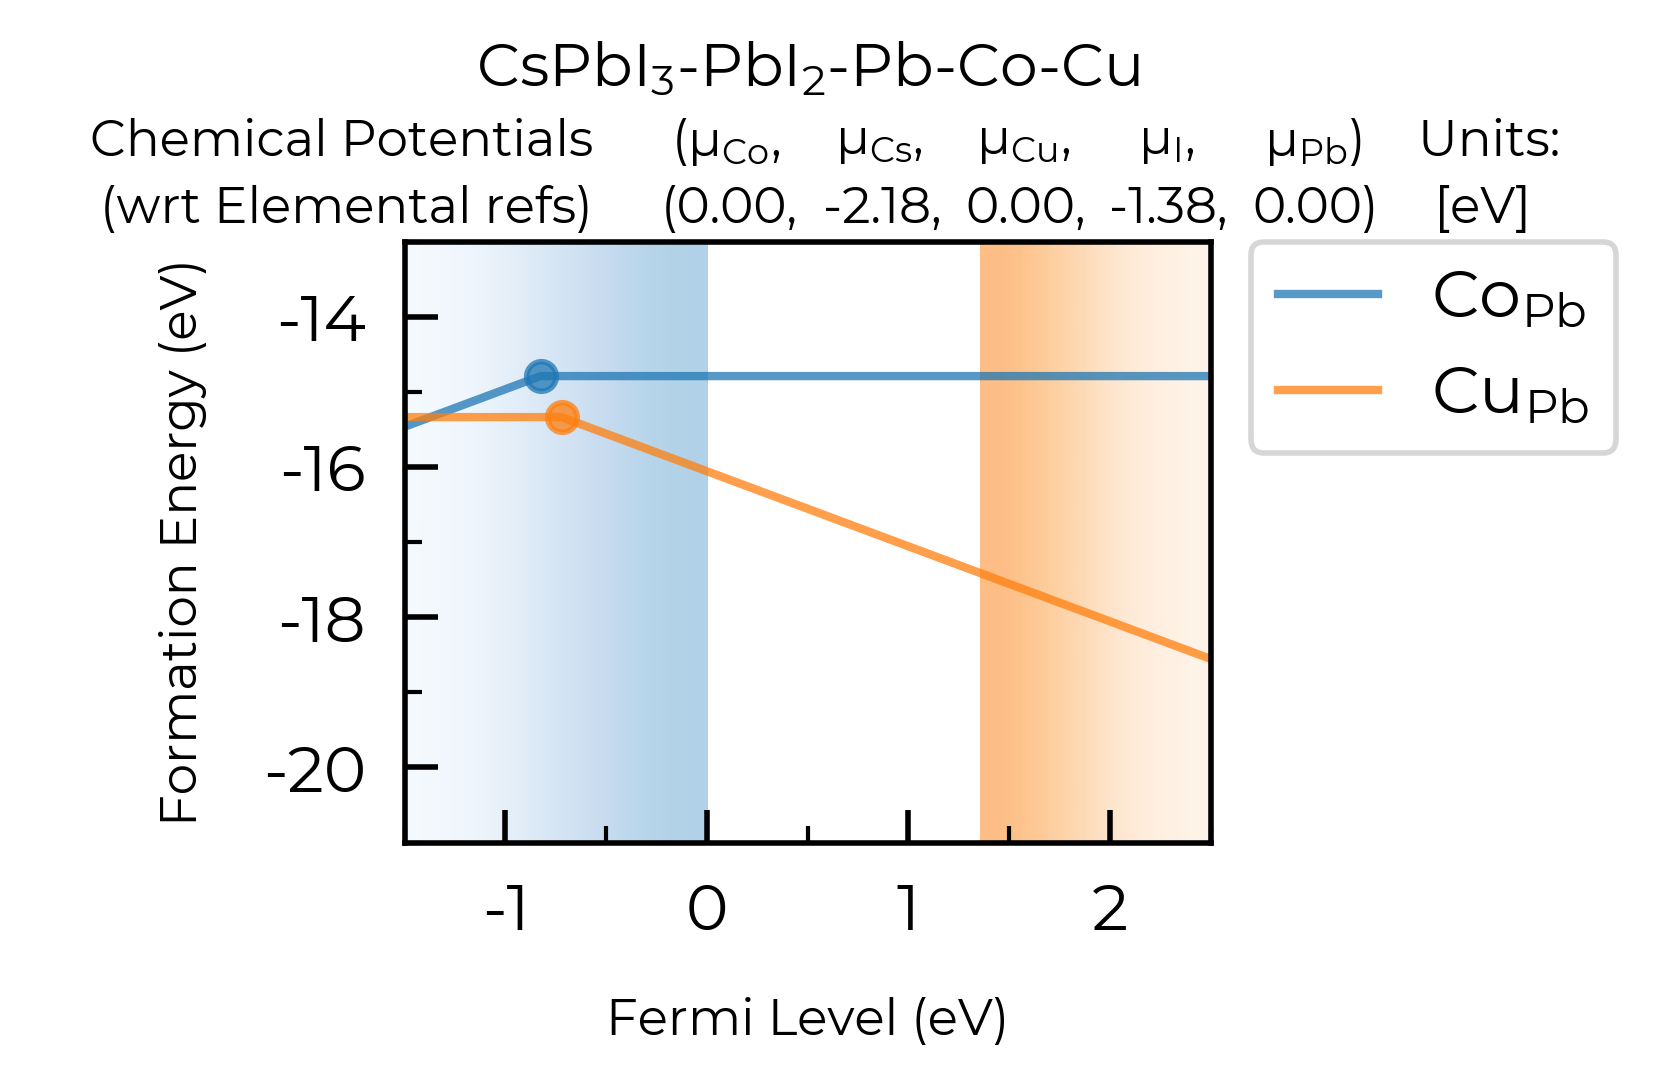

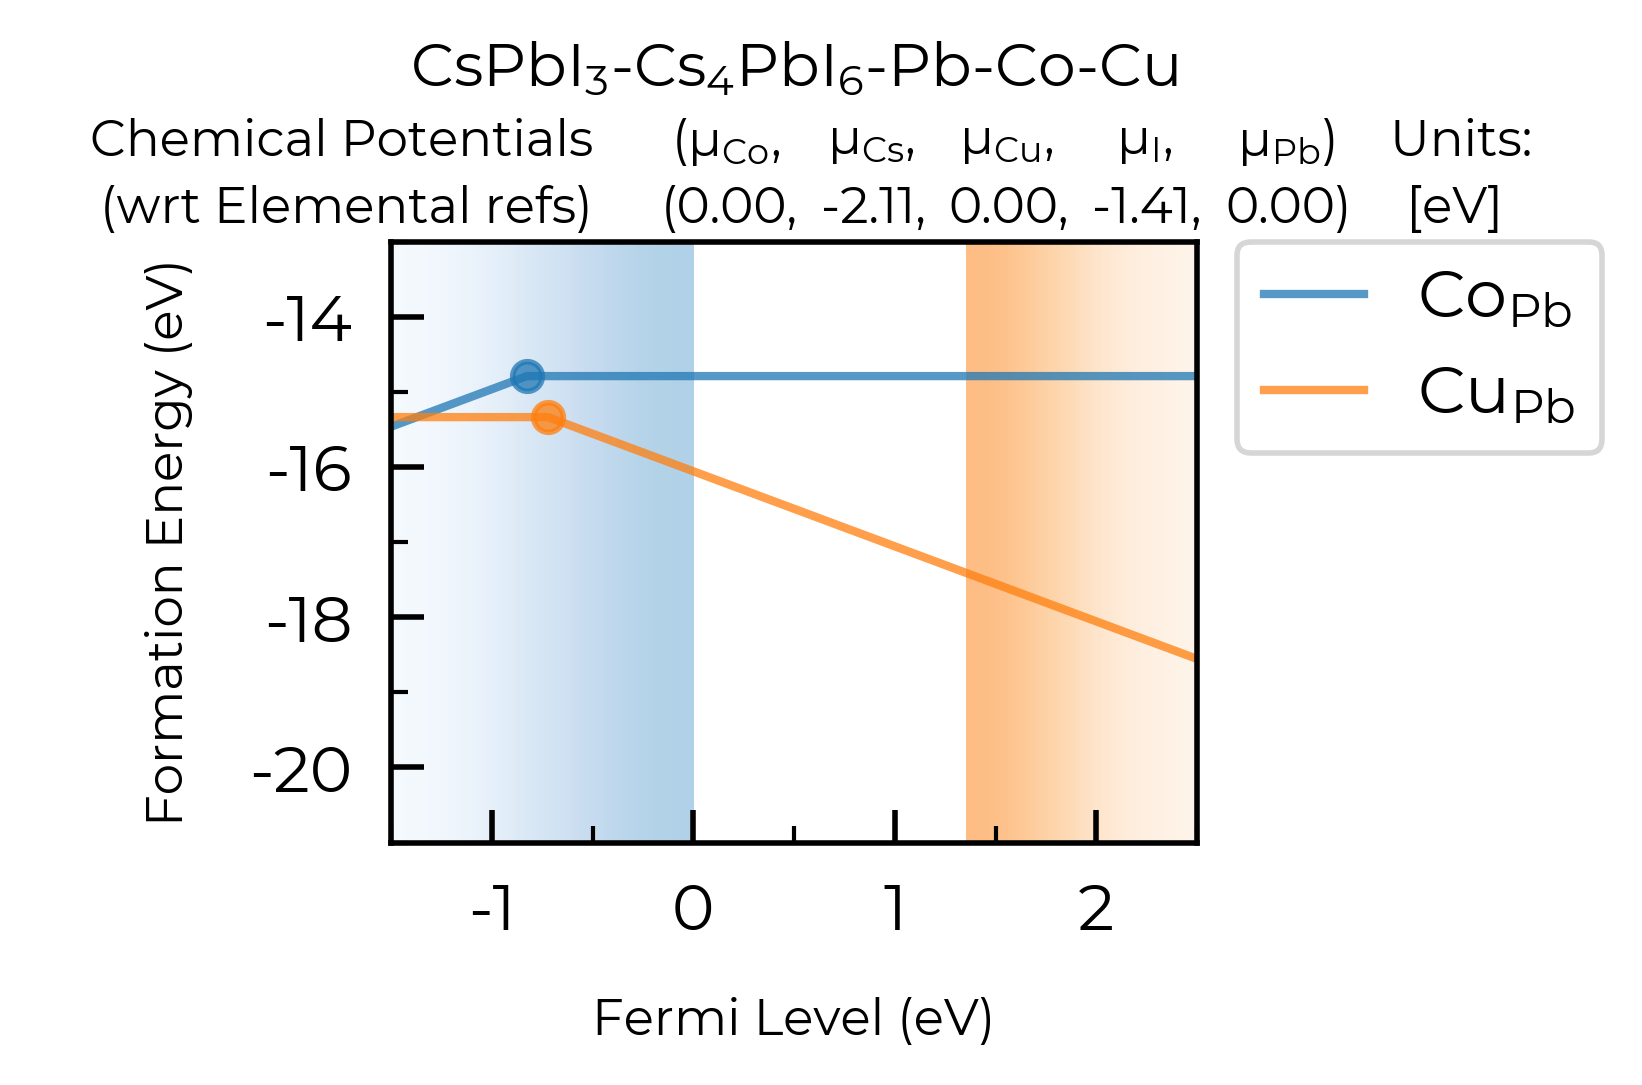

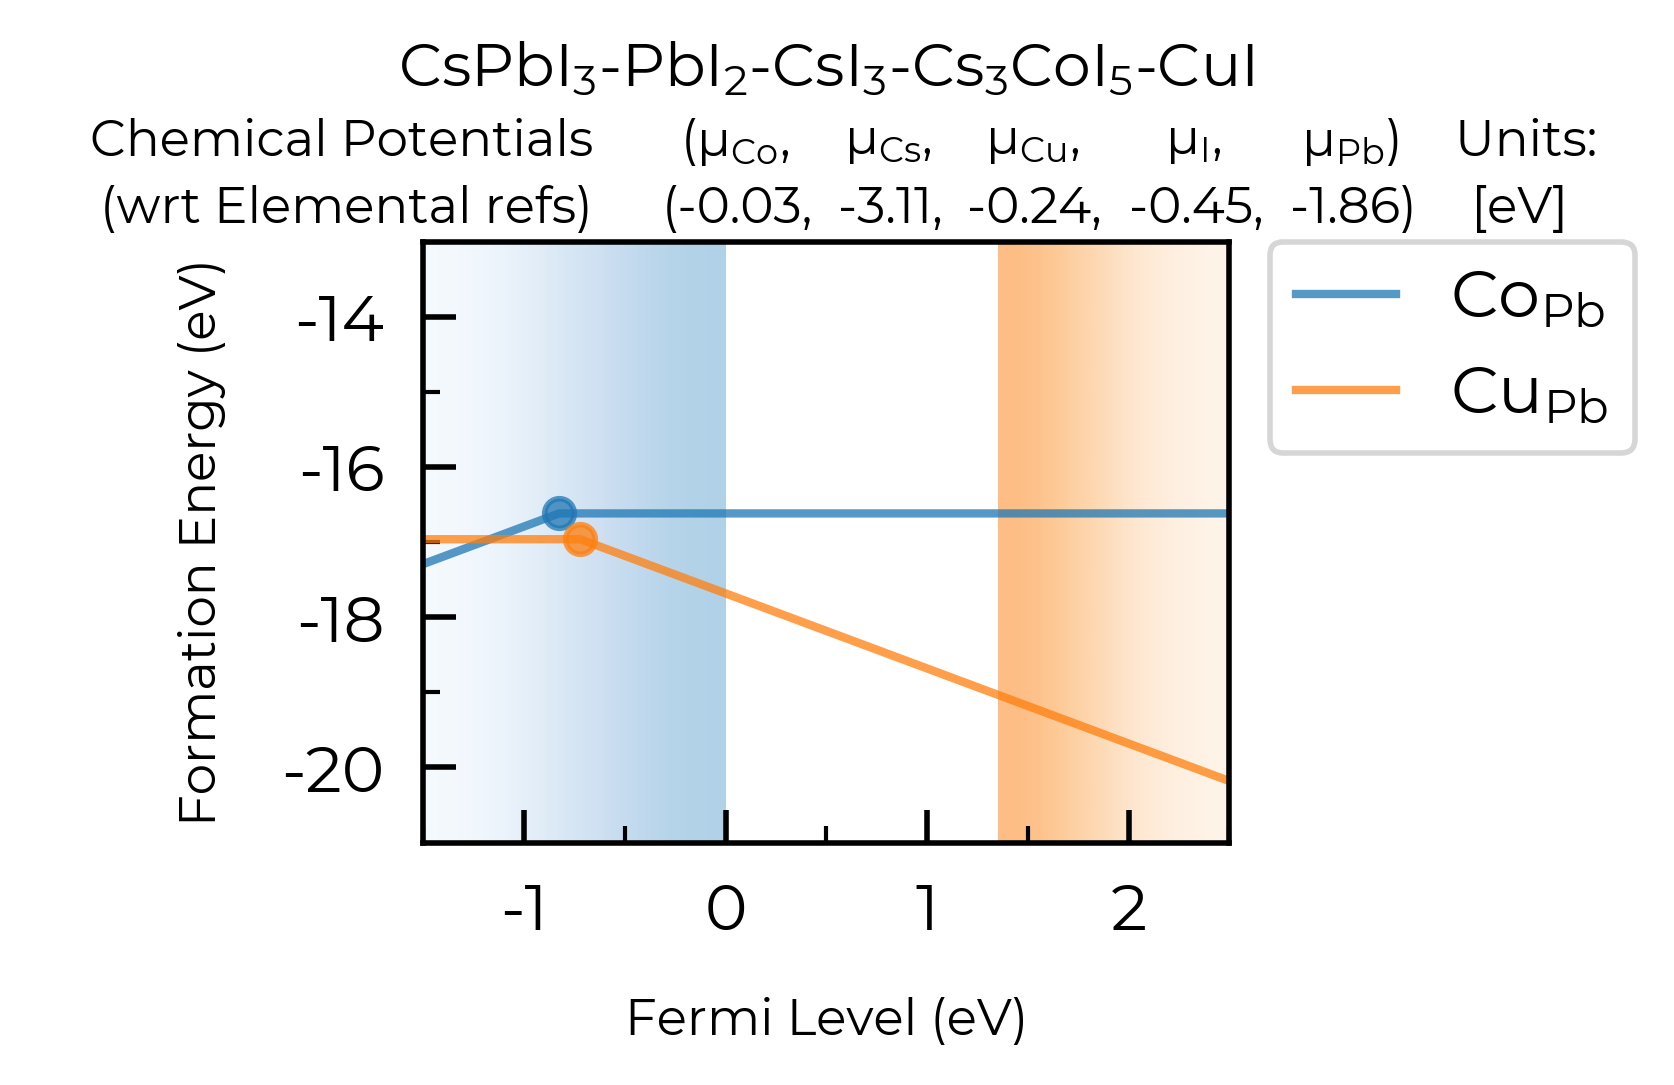

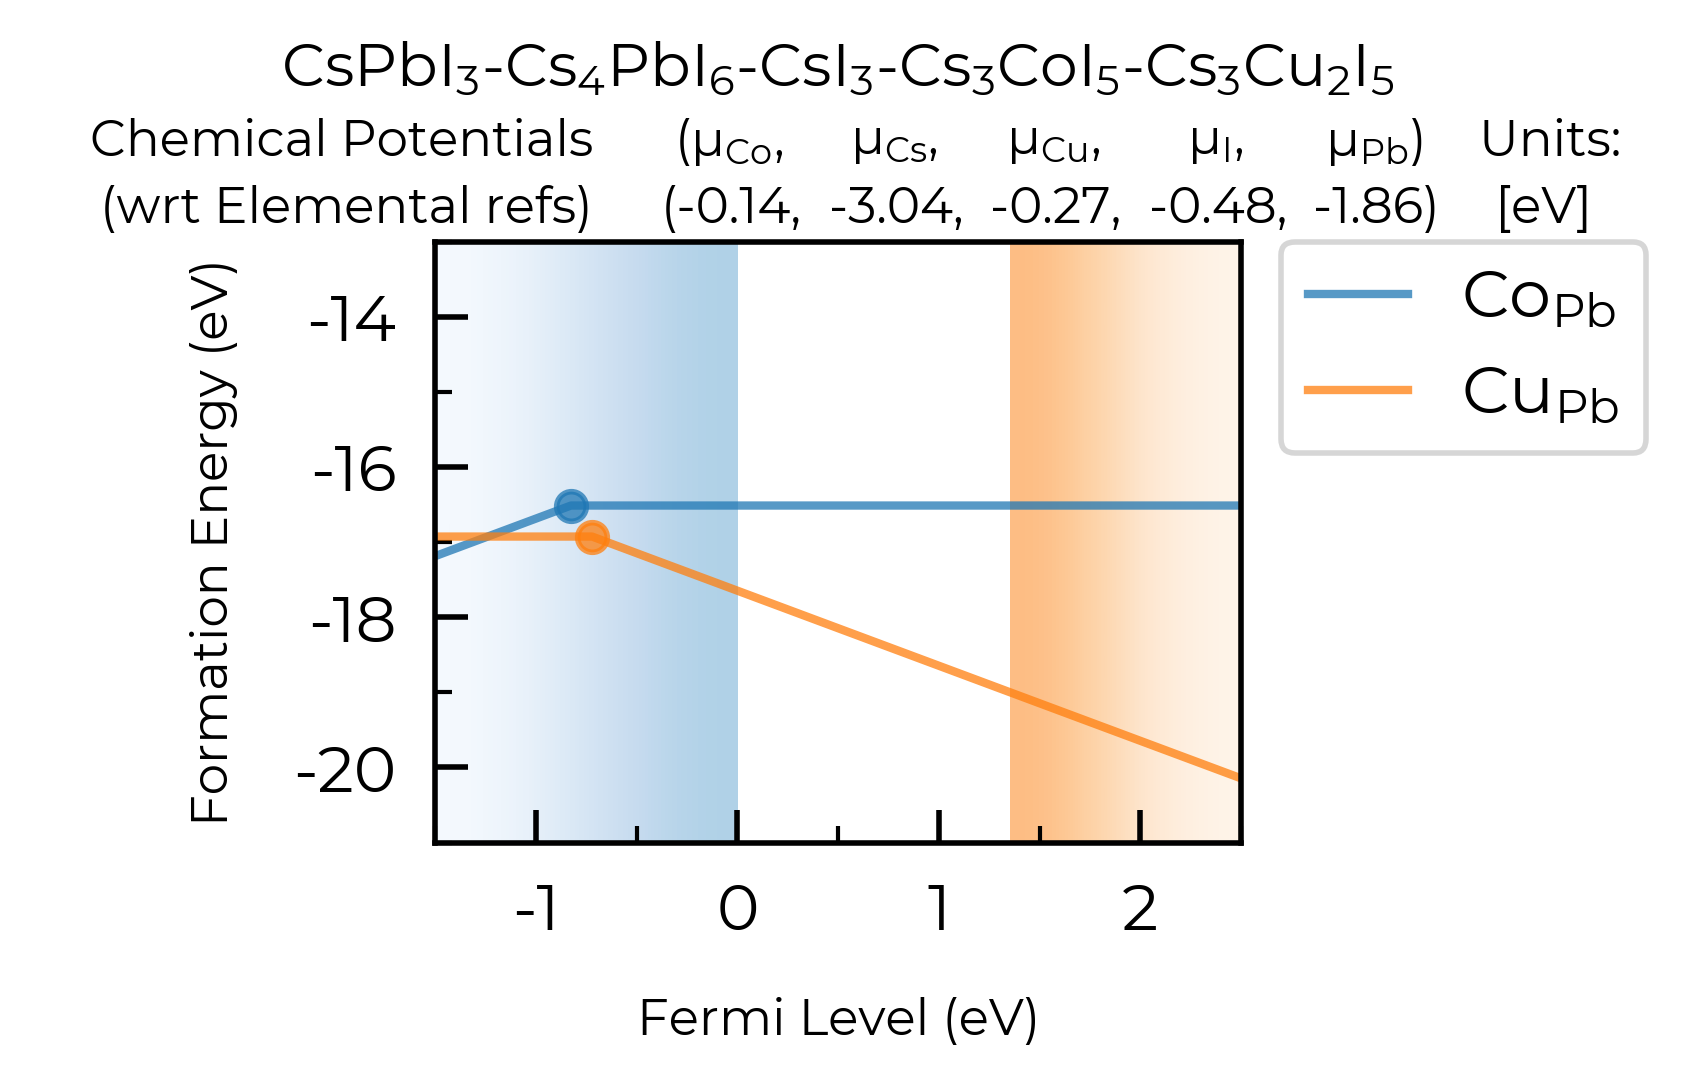

In [ ]:
xlim = [-1.5, 2.5]
defect_thermo = dp.get_defect_thermodynamics(chempots = cpa.chempots,
                                              el_refs = el_refs
                                             )  
figs = defect_thermo.plot(
                   xlim = xlim,
                   ylim = [-21,-13],
                   all_entries = False)  

plt.show()